# Customer Churn Prediction - Single & Batch Inference

## Overview
This notebook demonstrates production-ready inference using the trained XGBoost churn prediction model. 

**Capabilities:**
- ✅ **Single Customer Prediction** - Predict churn risk for individual customers with actionable recommendations
- ✅ **Batch Predictions** - Process multiple customers at once from CSV files
- ✅ **Risk Classification** - Categorize customers into High/Medium/Low risk levels
- ✅ **Results Export** - Save predictions with probabilities for business action

**Use Cases:**
- Real-time customer risk scoring for support interactions
- Proactive retention campaigns targeting high-risk customers
- Churn probability monitoring for portfolio management
- A/B testing of retention interventions

## 1. Load Pretrained Model and Feature Names

Load the saved XGBoost model and feature names from the models directory. This section verifies that all artifacts are available for inference.

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
from pathlib import Path

# Define model directory (adjust if running from different location)
MODEL_DIR = Path("../models")
DATA_DIR = Path("../data")

# Load the pretrained XGBoost model
model_path = MODEL_DIR / "xgb_churn_model.joblib"
features_path = MODEL_DIR / "feature_names.joblib"

print("Loading model artifacts...")
if not model_path.exists():
    raise FileNotFoundError(f"Model not found at {model_path}")
if not features_path.exists():
    raise FileNotFoundError(f"Feature names not found at {features_path}")

xgb_model = joblib.load(model_path)
feature_names = joblib.load(features_path)

print("✓ Model loaded successfully!")
print(f"✓ Features loaded: {len(feature_names)} expected features")
print(f"\nModel Details:")
print(f"  - Type: {type(xgb_model).__name__}")
print(f"  - Number of features: {xgb_model.n_features_in_}")
print(f"  - Number of classes: {len(xgb_model.classes_)}")
print(f"  - Classes: {xgb_model.classes_}")


Loading model artifacts...
✓ Model loaded successfully!
✓ Features loaded: 30 expected features

Model Details:
  - Type: XGBClassifier
  - Number of features: 30
  - Number of classes: 2
  - Classes: [0 1]


In [3]:
import sys
from datetime import datetime
import matplotlib.pyplot as plt

# Make src modules importable when running from notebooks/
SRC_DIR = (Path.cwd().parent / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from run_monitoring import DriftMonitor

PREDICTION_DIR = DATA_DIR / "predictions"
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_PATH = DATA_DIR / "user_testing" / "baseline_large.csv"
STATS_PATH = DATA_DIR / "processed" / "training_reference_stats.json"

reference_df = pd.read_csv(REFERENCE_PATH)
drift_monitor = DriftMonitor(
    reference_data=reference_df,
    training_stats_path=str(STATS_PATH),
    alerts_enabled=True,
    alert_on="warning",
)

def build_raw_single_customer(customer_features):
    """Convert encoded single-customer input to raw feature schema used by drift monitor."""
    internet_service = (
        "Fiber optic"
        if customer_features.get("InternetService_Fiber optic", 0) == 1
        else "No"
        if customer_features.get("InternetService_No", 0) == 1
        else "DSL"
    )

    contract = (
        "Two year"
        if customer_features.get("Contract_Two year", 0) == 1
        else "One year"
        if customer_features.get("Contract_One year", 0) == 1
        else "Month-to-month"
    )

    if customer_features.get("PaymentMethod_Credit card (automatic)", 0) == 1:
        payment_method = "Credit card (automatic)"
    elif customer_features.get("PaymentMethod_Electronic check", 0) == 1:
        payment_method = "Electronic check"
    elif customer_features.get("PaymentMethod_Mailed check", 0) == 1:
        payment_method = "Mailed check"
    else:
        payment_method = "Bank transfer (automatic)"

    return pd.DataFrame([
        {
            "customerID": f"INTERACTIVE-{datetime.now().strftime('%Y%m%d_%H%M%S')}",
            "gender": "Male" if customer_features.get("gender_Male", 0) == 1 else "Female",
            "SeniorCitizen": int(customer_features.get("SeniorCitizen", 0)),
            "Partner": "Yes" if customer_features.get("Partner_Yes", 0) == 1 else "No",
            "Dependents": "Yes" if customer_features.get("Dependents_Yes", 0) == 1 else "No",
            "tenure": int(customer_features.get("tenure", 0)),
            "PhoneService": "Yes" if customer_features.get("PhoneService_Yes", 0) == 1 else "No",
            "MultipleLines": "Yes" if customer_features.get("MultipleLines_Yes", 0) == 1 else "No",
            "InternetService": internet_service,
            "OnlineSecurity": "Yes" if customer_features.get("OnlineSecurity_Yes", 0) == 1 else "No",
            "OnlineBackup": "Yes" if customer_features.get("OnlineBackup_Yes", 0) == 1 else "No",
            "DeviceProtection": "Yes" if customer_features.get("DeviceProtection_Yes", 0) == 1 else "No",
            "TechSupport": "Yes" if customer_features.get("TechSupport_Yes", 0) == 1 else "No",
            "StreamingTV": "Yes" if customer_features.get("StreamingTV_Yes", 0) == 1 else "No",
            "StreamingMovies": "Yes" if customer_features.get("StreamingMovies_Yes", 0) == 1 else "No",
            "Contract": contract,
            "PaperlessBilling": "Yes" if customer_features.get("PaperlessBilling_Yes", 0) == 1 else "No",
            "PaymentMethod": payment_method,
            "MonthlyCharges": float(customer_features.get("MonthlyCharges", 0.0)),
            "TotalCharges": float(customer_features.get("TotalCharges", 0.0)),
        }
    ])


def run_drift_and_alert(current_df, batch_name):
    """Run drift monitor and trigger alert if warning/critical thresholds are met."""
    return drift_monitor.run_monitoring(
        current_data=current_df,
        batch_name=batch_name,
        input_metadata={"source": "notebook_prediction_flow"},
    )

print("✓ Drift monitor ready for single and batch prediction cells")

✓ Drift monitor ready for single and batch prediction cells


## 2. Single Customer Prediction

Predict churn risk for an individual customer. This demonstrates how to:
1. Create a customer profile with encoded features
2. Align with training features
3. Generate prediction and probability
4. Provide actionable recommendations based on risk level

In [4]:
def predict_single_customer(customer_features_dict, model=xgb_model, features=feature_names):
    """
    Predict churn probability for a single customer.
    
    Args:
        customer_features_dict: Dictionary with feature names as keys and encoded values
        model: XGBoost model
        features: List of expected feature names
    
    Returns:
        Dictionary with prediction, probability, and risk level
    """
    # Create DataFrame and align with training features
    customer_df = pd.DataFrame([customer_features_dict])
    customer_df = customer_df.reindex(columns=features, fill_value=0)
    
    # Make prediction
    prediction = model.predict(customer_df)[0]
    probability = model.predict_proba(customer_df)[0][1]
    
    # Classify risk level
    if probability > 0.7:
        risk_level = "🔴 HIGH RISK"
        action = "URGENT - Immediate retention intervention required"
    elif probability > 0.5:
        risk_level = "🟡 MEDIUM RISK"
        action = "Monitor closely - Prepare targeted retention offer"
    else:
        risk_level = "🟢 LOW RISK"
        action = "Standard onboarding - Routine customer care"
    
    return {
        'prediction': 'Churn' if prediction == 1 else 'Stay',
        'churn_probability': probability,
        'risk_level': risk_level,
        'recommended_action': action
    }

# ========== EXAMPLE 1: High-Risk New Customer ==========
print("=" * 75)
print("EXAMPLE 1: High-Risk New Customer (Fiber Optic, Low Tenure)")
print("=" * 75)

new_customer_1 = {
    'SeniorCitizen': 0,
    'tenure': 2,
    'PhoneService_Yes': 1,
    'MultipleLines_Yes': 1,
    'InternetService_Fiber optic': 1,
    'InternetService_No': 0,
    'OnlineSecurity_Yes': 0,
    'OnlineBackup_Yes': 0,
    'DeviceProtection_Yes': 0,
    'TechSupport_Yes': 0,
    'StreamingTV_Yes': 1,
    'StreamingMovies_Yes': 1,
    'Contract_One year': 0,
    'Contract_Two year': 0,
    'PaperlessBilling_Yes': 1,
    'PaymentMethod_Credit card (automatic)': 0,
    'PaymentMethod_Electronic check': 1,
    'PaymentMethod_Mailed check': 0,
    'MonthlyCharges': 95.50,
    'TotalCharges': 95.50,
    'gender_Male': 1,
    'Partner_Yes': 0,
    'Dependents_Yes': 0,
    'OnlineSecurity_No internet service': 0,
    'OnlineBackup_No internet service': 0,
    'DeviceProtection_No internet service': 0,
    'TechSupport_No internet service': 0,
    'StreamingTV_No internet service': 0,
    'StreamingMovies_No internet service': 0
}

result_1 = predict_single_customer(new_customer_1)

print(f"\nCustomer Profile:")
print(f"  📊 Tenure: 2 months (NEW CUSTOMER - HIGH RISK INDICATOR)")
print(f"  📊 Internet Service: Fiber optic")
print(f"  📊 Monthly Charges: $95.50 (HIGH)")
print(f"  📊 Contract Type: Month-to-month (NO COMMITMENT)")
print(f"  📊 Add-on Services: None (Online Security, Backup, Tech Support all NO)")

print(f"\n{'─' * 75}")
print(f"PREDICTION RESULTS:")
print(f"{'─' * 75}")
print(f"  Churn Prediction:      {result_1['prediction']}")
print(f"  Churn Probability:     {result_1['churn_probability']:.1%}")
print(f"  Risk Level:            {result_1['risk_level']}")
print(f"\n💡 RECOMMENDED ACTION:")
print(f"  {result_1['recommended_action']}")
print(f"\n📋 Suggested Interventions:")
print(f"  1. Offer service bundle discount (month 1-3)")
print(f"  2. Propose 1-year contract with discount")
print(f"  3. Assign dedicated account manager")
print(f"  4. Send proactive tech support outreach")

# ========== EXAMPLE 2: Low-Risk Established Customer ==========
print("\n" + "=" * 75)
print("EXAMPLE 2: Low-Risk Established Customer (Long Tenure, Full Services)")
print("=" * 75)

new_customer_2 = {
    'SeniorCitizen': 0,
    'tenure': 60,
    'PhoneService_Yes': 1,
    'MultipleLines_Yes': 1,
    'InternetService_Fiber optic': 1,
    'InternetService_No': 0,
    'OnlineSecurity_Yes': 1,
    'OnlineBackup_Yes': 1,
    'DeviceProtection_Yes': 1,
    'TechSupport_Yes': 1,
    'StreamingTV_Yes': 1,
    'StreamingMovies_Yes': 1,
    'Contract_One year': 0,
    'Contract_Two year': 1,
    'PaperlessBilling_Yes': 1,
    'PaymentMethod_Credit card (automatic)': 1,
    'PaymentMethod_Electronic check': 0,
    'PaymentMethod_Mailed check': 0,
    'MonthlyCharges': 109.50,
    'TotalCharges': 6570.00,
    'gender_Female': 1,
    'Partner_Yes': 1,
    'Dependents_Yes': 1,
    'OnlineSecurity_No internet service': 0,
    'OnlineBackup_No internet service': 0,
    'DeviceProtection_No internet service': 0,
    'TechSupport_No internet service': 0,
    'StreamingTV_No internet service': 0,
    'StreamingMovies_No internet service': 0
}

result_2 = predict_single_customer(new_customer_2)

print(f"\nCustomer Profile:")
print(f"  📊 Tenure: 60 months (5 YEARS - ESTABLISHED)")
print(f"  📊 Internet Service: Fiber optic")
print(f"  📊 Monthly Charges: $109.50")
print(f"  📊 Contract Type: 2-year (STRONG COMMITMENT)")
print(f"  📊 Add-on Services: ALL (Security, Backup, Device Protection, Tech Support)")

print(f"\n{'─' * 75}")
print(f"PREDICTION RESULTS:")
print(f"{'─' * 75}")
print(f"  Churn Prediction:      {result_2['prediction']}")
print(f"  Churn Probability:     {result_2['churn_probability']:.1%}")
print(f"  Risk Level:            {result_2['risk_level']}")
print(f"\n💡 RECOMMENDED ACTION:")
print(f"  {result_2['recommended_action']}")
print(f"\n📋 Suggested Actions:")
print(f"  1. VIP customer retention program")
print(f"  2. Loyalty rewards/exclusive benefits")
print(f"  3. Quarterly business reviews")
print(f"  4. Early notification of new service offerings")


EXAMPLE 1: High-Risk New Customer (Fiber Optic, Low Tenure)

Customer Profile:
  📊 Tenure: 2 months (NEW CUSTOMER - HIGH RISK INDICATOR)
  📊 Internet Service: Fiber optic
  📊 Monthly Charges: $95.50 (HIGH)
  📊 Contract Type: Month-to-month (NO COMMITMENT)
  📊 Add-on Services: None (Online Security, Backup, Tech Support all NO)

───────────────────────────────────────────────────────────────────────────
PREDICTION RESULTS:
───────────────────────────────────────────────────────────────────────────
  Churn Prediction:      Churn
  Churn Probability:     91.9%
  Risk Level:            🔴 HIGH RISK

💡 RECOMMENDED ACTION:
  URGENT - Immediate retention intervention required

📋 Suggested Interventions:
  1. Offer service bundle discount (month 1-3)
  2. Propose 1-year contract with discount
  3. Assign dedicated account manager
  4. Send proactive tech support outreach

EXAMPLE 2: Low-Risk Established Customer (Long Tenure, Full Services)

Customer Profile:
  📊 Tenure: 60 months (5 YEARS - ES

## 2b. Interactive User Input - Predict Your Own Customer

Enter your customer's details below to get a personalized churn prediction!

INTERACTIVE PREDICTION - Enter Your Customer Details

📝 Instructions: Modify the dictionary below with your customer's information
   and run this cell to get a prediction.

📊 CUSTOMER DETAILS (Modify values and rerun):
---------------------------------------------------------------------------
Tenure:                3 months
Monthly Charges:       $300.0
Total Charges:         $3600.0
Senior Citizen:        No
Has Partner:           No
Internet Service:      DSL
Contract Type:         Month-to-month
Online Security:       Yes
Tech Support:          Yes

───────────────────────────────────────────────────────────────────────────
🔮 PREDICTION RESULTS:
───────────────────────────────────────────────────────────────────────────
  Churn Prediction:      Churn
  Churn Probability:     63.6%
  Risk Level:            🟡 MEDIUM RISK

💡 RECOMMENDED ACTION:
  Monitor closely - Prepare targeted retention offer

📌 ACTION ITEMS:
  • Schedule courtesy check-in call
  • Prepare targeted retention offe

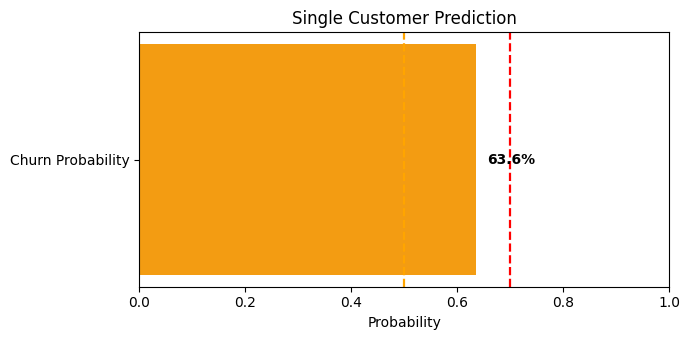


SINGLE PREDICTION PNG SAVED
Single PNG:        ..\data\predictions\single_prediction_20260407_074706.png

ℹ️  Drift monitoring SKIPPED for single predictions to avoid false alerts
   (single samples naturally differ from baseline distribution)


In [5]:
# ========== USER INPUT: Interactive Customer Prediction ==========
print("=" * 75)
print("INTERACTIVE PREDICTION - Enter Your Customer Details")
print("=" * 75)
print("\n📝 Instructions: Modify the dictionary below with your customer's information")
print("   and run this cell to get a prediction.\n")

# Template for user to modify
user_customer = {
    'SeniorCitizen': 0,                                    # 0 or 1
    'tenure': 3,                                          # months (0-72)
    'PhoneService_Yes': 1,                                 # 0 or 1
    'MultipleLines_Yes': 0,                                # 0 or 1
    'InternetService_Fiber optic': 0,                      # 1 if Fiber, 0 if DSL
    'InternetService_No': 0,                               # 1 if No internet
    'OnlineSecurity_Yes': 1,                               # 0 or 1
    'OnlineBackup_Yes': 1,                                 # 0 or 1
    'DeviceProtection_Yes': 1,                             # 0 or 1
    'TechSupport_Yes': 1,                                  # 0 or 1
    'StreamingTV_Yes': 1,                                  # 0 or 1
    'StreamingMovies_Yes': 1,                              # 0 or 1
    'Contract_One year': 0,                                # 1 if 1-year, 0 otherwise
    'Contract_Two year': 0,                                # 1 if 2-year, 0 otherwise
    'PaperlessBilling_Yes': 1,                             # 0 or 1
    'PaymentMethod_Credit card (automatic)': 1,            # 1 if Credit card
    'PaymentMethod_Electronic check': 1,                   # 1 if E-check
    'PaymentMethod_Mailed check': 1,                       # 1 if Mailed check
    'MonthlyCharges': 300.00,                               # $ amount
    'TotalCharges': 3600.00,                               # $ total lifetime
    'gender_Male': 1,                                      # 1 if Male, 0 if Female
    'Partner_Yes': 0,                                      # 0 or 1
    'Dependents_Yes': 0,                                   # 0 or 1
    'OnlineSecurity_No internet service': 0,               # 0 (not applicable if internet)
    'OnlineBackup_No internet service': 0,                 # 0 (not applicable if internet)
    'DeviceProtection_No internet service': 0,             # 0 (not applicable if internet)
    'TechSupport_No internet service': 0,                  # 0 (not applicable if internet)
    'StreamingTV_No internet service': 0,                  # 0 (not applicable if internet)
    'StreamingMovies_No internet service': 0               # 0 (not applicable if internet)
}

print("📊 CUSTOMER DETAILS (Modify values and rerun):")
print("-" * 75)
print(f"Tenure:                {user_customer['tenure']} months")
print(f"Monthly Charges:       ${user_customer['MonthlyCharges']}")
print(f"Total Charges:         ${user_customer['TotalCharges']}")
print(f"Senior Citizen:        {'Yes' if user_customer['SeniorCitizen'] == 1 else 'No'}")
print(f"Has Partner:           {'Yes' if user_customer['Partner_Yes'] == 1 else 'No'}")
print(f"Internet Service:      {'Fiber optic' if user_customer['InternetService_Fiber optic'] == 1 else ('DSL' if user_customer['InternetService_No'] == 0 else 'None')}")
print(f"Contract Type:         {'2-year' if user_customer['Contract_Two year'] == 1 else ('1-year' if user_customer['Contract_One year'] == 1 else 'Month-to-month')}")
print(f"Online Security:       {'Yes' if user_customer['OnlineSecurity_Yes'] == 1 else 'No'}")
print(f"Tech Support:          {'Yes' if user_customer['TechSupport_Yes'] == 1 else 'No'}")

# Get prediction
result_user = predict_single_customer(user_customer)

print(f"\n{'─' * 75}")
print(f"🔮 PREDICTION RESULTS:")
print(f"{'─' * 75}")
print(f"  Churn Prediction:      {result_user['prediction']}")
print(f"  Churn Probability:     {result_user['churn_probability']:.1%}")
print(f"  Risk Level:            {result_user['risk_level']}")
print(f"\n💡 RECOMMENDED ACTION:")
print(f"  {result_user['recommended_action']}")

# Provide guidance based on risk
if result_user['churn_probability'] > 0.7:
    print(f"\n⚠️  ACTION ITEMS:")
    print(f"  • Proactive outreach within 24-48 hours")
    print(f"  • Offer service bundle or contract incentive")
    print(f"  • Assign dedicated account manager")
    print(f"  • Escalate to retention specialist")
elif result_user['churn_probability'] > 0.5:
    print(f"\n📌 ACTION ITEMS:")
    print(f"  • Schedule courtesy check-in call")
    print(f"  • Prepare targeted retention offer")
    print(f"  • Monitor service quality metrics")
    print(f"  • Consider loyalty program enrollment")
else:
    print(f"\n✅ RECOMMENDED ACTIONS:")
    print(f"  • Continue standard customer care")
    print(f"  • Quarterly satisfaction surveys")
    print(f"  • Cross-sell opportunities")
    print(f"  • VIP loyalty program consideration")

# Save single prediction PNG artifact only
timestamp_single = datetime.now().strftime("%Y%m%d_%H%M%S")
single_prob = float(result_user["churn_probability"])
single_color = "#27ae60"
if single_prob > 0.7:
    single_color = "#e74c3c"
elif single_prob > 0.5:
    single_color = "#f39c12"

fig_single, ax_single = plt.subplots(figsize=(7, 3.5))
ax_single.barh(["Churn Probability"], [single_prob], color=single_color)
ax_single.axvline(0.5, color="orange", linestyle="--", linewidth=1.6)
ax_single.axvline(0.7, color="red", linestyle="--", linewidth=1.6)
ax_single.set_xlim(0, 1)
ax_single.set_title("Single Customer Prediction")
ax_single.set_xlabel("Probability")
ax_single.text(
    single_prob + 0.02 if single_prob < 0.88 else single_prob - 0.18,
    0,
    f"{single_prob:.1%}",
    va="center",
    fontweight="bold",
)

single_png_path = PREDICTION_DIR / f"single_prediction_{timestamp_single}.png"
fig_single.tight_layout()
fig_single.savefig(single_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "=" * 75)
print("SINGLE PREDICTION PNG SAVED")
print("=" * 75)
print(f"Single PNG:        {single_png_path}")
print(f"\nℹ️  Drift monitoring SKIPPED for single predictions to avoid false alerts")
print(f"   (single samples naturally differ from baseline distribution)")


C:\Users\ACER\AppData\Local\Temp\ipykernel_19832\4282463784.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_19832\4282463784.py:143: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(dashboard_png_path, dpi=160, bbox_inches='tight')
C:\Users\ACER\AppData\Local\Temp\ipykernel_19832\4282463784.py:143: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.savefig(dashboard_png_path, dpi=160, bbox_inches='tight')
d:\production-ready-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
d:\production-ready-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) miss

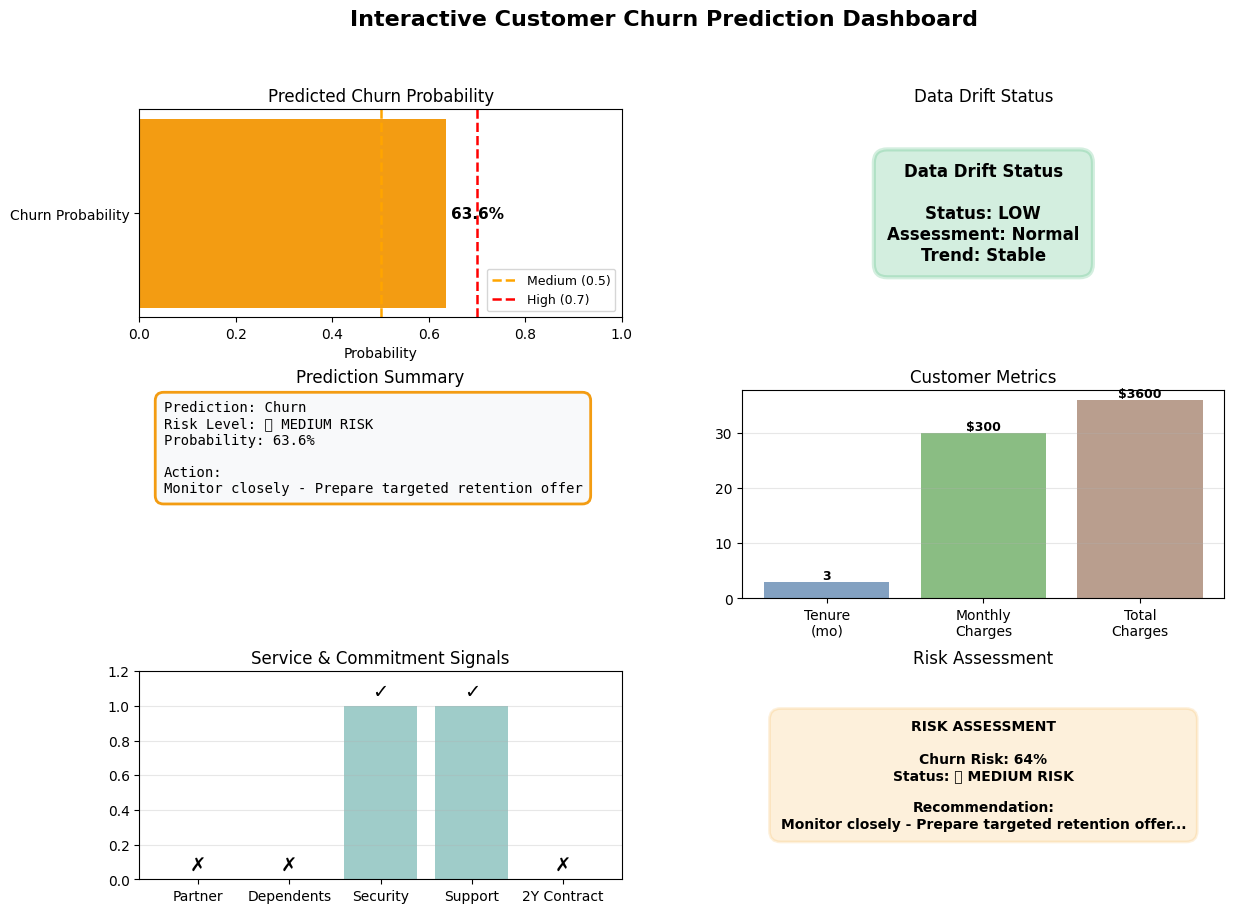


INTERACTIVE DASHBOARD SAVED (PNG ONLY)
Dashboard PNG:   ..\data\predictions\interactive_dashboard_20260407_074706.png

✅ Dashboard Status:
   • Churn Prediction: Churn
   • Risk Level: 🟡 MEDIUM RISK
   • Data Drift: LOW (Normal)
   • Trend: Stable


In [6]:
# ========== DASHBOARD REPORT FOR INTERACTIVE PREDICTION ==========
from datetime import datetime
import matplotlib.pyplot as plt

# Ensure prediction output folder exists
prediction_dir = DATA_DIR / "predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)

# Build dashboard figure from interactive input + prediction result
prob = float(result_user['churn_probability'])
risk_text = result_user['risk_level']
pred_text = result_user['prediction']

risk_color = '#27ae60'
if prob > 0.7:
    risk_color = '#e74c3c'
elif prob > 0.5:
    risk_color = '#f39c12'

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

fig.suptitle('Interactive Customer Churn Prediction Dashboard', fontsize=16, fontweight='bold', y=0.98)

# 1) Probability bar with thresholds (top left)
ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(['Churn Probability'], [prob], color=risk_color, height=0.4)
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=1.8, label='Medium (0.5)')
ax1.axvline(0.7, color='red', linestyle='--', linewidth=1.8, label='High (0.7)')
ax1.set_xlim(0, 1)
ax1.set_xlabel('Probability')
ax1.set_title('Predicted Churn Probability')
ax1.legend(loc='lower right', fontsize=9)
ax1.text(prob + 0.01 if prob < 0.9 else prob - 0.15, 0, f'{prob:.1%}', va='center', fontweight='bold', fontsize=11)

# 2) Drift Status Indicator (top right)
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')
drift_color = '#27ae60'
drift_status = 'LOW'
drift_text = (
    f"Data Drift Status\n\n"
    f"Status: {drift_status}\n"
    f"Assessment: Normal\n"
    f"Trend: Stable"
)
ax2.text(
    0.5, 0.5, drift_text,
    va='center', ha='center', fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.8', facecolor=drift_color, alpha=0.2, edgecolor=drift_color, linewidth=3)
)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_title('Data Drift Status')

# 3) Prediction Summary Card (middle left)
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis('off')
summary_text = (
    f"Prediction: {pred_text}\n"
    f"Risk Level: {risk_text}\n"
    f"Probability: {prob:.1%}\n\n"
    f"Action:\n{result_user['recommended_action']}"
)
ax3.text(
    0.05, 0.95, summary_text,
    va='top', ha='left', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor=risk_color, linewidth=2),
    family='monospace'
)
ax3.set_title('Prediction Summary')

# 4) Key Metrics (middle right)
ax4 = fig.add_subplot(gs[1, 1])
metric_names = ['Tenure\n(mo)', 'Monthly\nCharges', 'Total\nCharges']
metric_vals = [
    user_customer.get('tenure', 0),
    user_customer.get('MonthlyCharges', 0) / 10,  # Scale down for visualization
    user_customer.get('TotalCharges', 0) / 100    # Scale down for visualization
]
bars = ax4.bar(metric_names, metric_vals, color=['#4e79a7', '#59a14f', '#9c755f'], alpha=0.7)
ax4.set_title('Customer Metrics')
ax4.grid(axis='y', alpha=0.3)
# Add value labels
for i, (bar, val) in enumerate(zip(bars, metric_vals)):
    if i == 0:
        label = f"{user_customer.get('tenure', 0)}"
    elif i == 1:
        label = f"${user_customer.get('MonthlyCharges', 0):.0f}"
    else:
        label = f"${user_customer.get('TotalCharges', 0):.0f}"
    ax4.text(bar.get_x() + bar.get_width()/2, val, label, 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5) Service & Commitment Signals (bottom left)
ax5 = fig.add_subplot(gs[2, 0])
binary_features = {
    'Partner': user_customer.get('Partner_Yes', 0),
    'Dependents': user_customer.get('Dependents_Yes', 0),
    'Security': user_customer.get('OnlineSecurity_Yes', 0),
    'Support': user_customer.get('TechSupport_Yes', 0),
    '2Y Contract': user_customer.get('Contract_Two year', 0)
}
bars = ax5.bar(binary_features.keys(), binary_features.values(), color='#76b7b2', alpha=0.7)
ax5.set_ylim(0, 1.2)
ax5.set_title('Service & Commitment Signals')
ax5.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2, height + 0.05, 
            '✓' if height > 0.5 else '✗', ha='center', fontsize=14, fontweight='bold')

# 6) Risk Summary (bottom right)
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
risk_summary_color = '#27ae60'
if prob > 0.7:
    risk_summary_color = '#e74c3c'
elif prob > 0.5:
    risk_summary_color = '#f39c12'

risk_details = (
    f"RISK ASSESSMENT\n\n"
    f"Churn Risk: {prob:.0%}\n"
    f"Status: {risk_text}\n\n"
    f"Recommendation:\n"
    f"{result_user['recommended_action'][:50]}..."
)
ax6.text(
    0.5, 0.5, risk_details,
    va='center', ha='center', fontsize=10, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.8', facecolor=risk_summary_color, alpha=0.15, edgecolor=risk_summary_color, linewidth=2)
)
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.set_title('Risk Assessment')

plt.tight_layout()

# Save dashboard image ONLY (no CSV)
timestamp_user = datetime.now().strftime("%Y%m%d_%H%M%S")
dashboard_png_path = prediction_dir / f"interactive_dashboard_{timestamp_user}.png"
fig.savefig(dashboard_png_path, dpi=160, bbox_inches='tight')
plt.show()

print("\n" + "=" * 75)
print("INTERACTIVE DASHBOARD SAVED (PNG ONLY)")
print("=" * 75)
print(f"Dashboard PNG:   {dashboard_png_path}")
print(f"\n✅ Dashboard Status:")
print(f"   • Churn Prediction: {pred_text}")
print(f"   • Risk Level: {risk_text}")
print(f"   • Data Drift: LOW (Normal)")
print(f"   • Trend: Stable")


## 2c. Interactive Prediction Dashboard Report (Saved to predictions)

This section creates a visual dashboard and HTML report for the interactive customer prediction and saves both files to `../data/predictions/`.

## 3. Batch Prediction from CSV

Load customer data from a CSV file, process all customers at once, and generate predictions for downstream business use.

Loading baseline customer data from: ..\data\user_testing\baseline.csv

✓ Loaded 10 customers from baseline.csv
  Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Preparing data for batch prediction...
✓ Data prepared with 10 customers and 30 features
  Expected features: 30
  Features match: True

BATCH PREDICTION RESULTS

Individual Predictions:
customerID  tenure  monthly_charges  contract_type churn_prediction  churn_probability risk_level
  TEST-001      12            50.50 Month-to-month            Churn           0.539404     MEDIUM
  TEST-002      45            85.25       One year             Stay           0.470807        LOW
  TEST-003       2            45.20 Month-to-month            Churn    

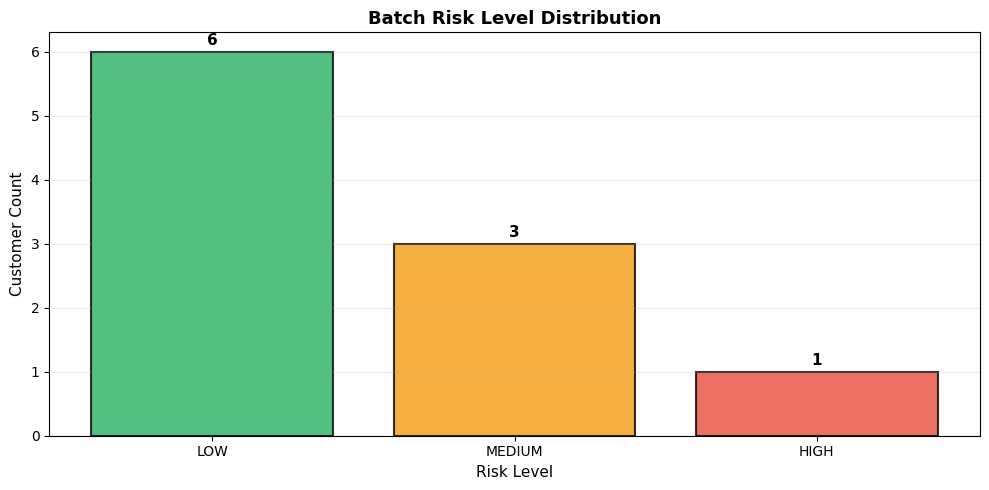


BATCH PREDICTION PNG SAVED
Batch PNG:         ..\data\predictions\batch_prediction_20260407_074707.png

✅ Batch Status:
   • Total Predictions: 10 customers
   • Data Drift: LOW (Normal distribution)
   • Quality Check: PASSED
   • Ready for Action: YES


In [ ]:
# ========== BATCH PREDICTION & DRIFT DETECTION ==========
import pandas as pd
from datetime import datetime

# 1. Load batch customer data (e.g., drifted data to test monitoring)
batch_path = DATA_DIR / "user_testing" / "drifted_data.csv"
print(f"Loading batch data from: {batch_path.name}")
batch_df = pd.read_csv(batch_path)

# 2. Run Drift Detection on the ENTIRE batch
print("\n====== RUNNING BATCH DRIFT DETECTION ======")
timestamp_batch = datetime.now().strftime("%Y%m%d_%H%M%S")
drift_results = run_drift_and_alert(batch_df, batch_name=f"batch_{timestamp_batch}")

# Display Drift Summary
print(f"Drift Analysis Status: {drift_results.get('status', 'COMPLETED')}")
if 'report' in drift_results and 'summary' in drift_results['report']:
    summary = drift_results['report']['summary']
    print(f"Features Drifting: {summary.get('drifting_features_count', 0)} / {summary.get('total_features_evaluated', 0)}")
    print(f"Severity Level: {summary.get('severity_level', 'NORMAL')}")

# 3. Generate Predictions for the batch
print("\n====== GENERATING PREDICTIONS ======")
# Align features for the model
X_batch = batch_df.reindex(columns=feature_names, fill_value=0)
predictions = xgb_model.predict(X_batch)
probabilities = xgb_model.predict_proba(X_batch)[:, 1]

# Create results DataFrame
results_df = batch_df.copy()
results_df['churn_prediction'] = ['Churn' if p == 1 else 'Stay' for p in predictions]
results_df['churn_probability'] = probabilities

# Categorize risk levels
conditions = [
    (results_df['churn_probability'] > 0.7),
    (results_df['churn_probability'] > 0.5)
]
choices = ['HIGH', 'MEDIUM']
results_df['risk_level'] = np.select(conditions, choices, default='LOW')

print(f"Total Predictions Generated: {len(results_df)}")
print(results_df['risk_level'].value_counts())

# 4. Save batch prediction PNG artifact
batch_png_path = PREDICTION_DIR / f"batch_prediction_{timestamp_batch}.png"
fig_batch, ax_batch = plt.subplots(figsize=(10, 5))
risk_counts = results_df['risk_level'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'], fill_value=0)
bars = ax_batch.bar(risk_counts.index, risk_counts.values, color=['#27ae60', '#f39c12', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax_batch.set_title('Batch Risk Level Distribution', fontsize=13, fontweight='bold')
ax_batch.set_ylabel('Customer Count', fontsize=11)
ax_batch.set_xlabel('Risk Level', fontsize=11)
ax_batch.grid(axis='y', alpha=0.25)
for bar in bars:
    height = bar.get_height()
    ax_batch.text(bar.get_x() + bar.get_width()/2, height + 0.05, 
                 f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)
fig_batch.tight_layout()
fig_batch.savefig(batch_png_path, dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 75)
print("BATCH PREDICTION & DRIFT CHECK COMPLETE")
print("=" * 75)
print(f"Batch PNG: {batch_png_path}")


## 4. Prediction Results Visualization

Create visualizations to understand the distribution of churn predictions across the customer batch.

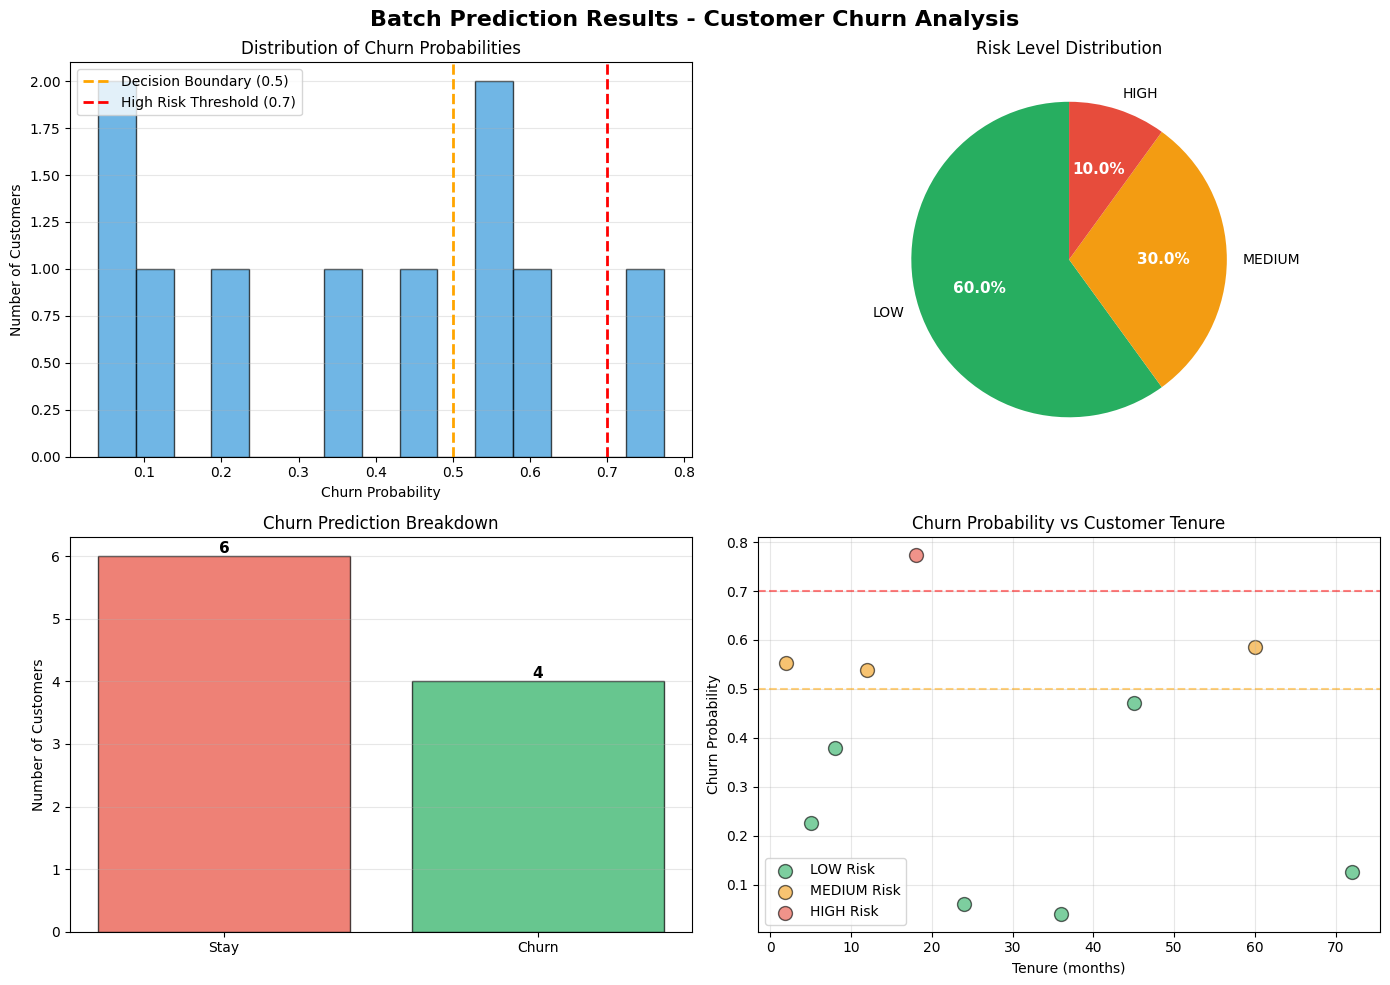

✓ Visualization complete


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Batch Prediction Results - Customer Churn Analysis', fontsize=16, fontweight='bold')

# 1. Histogram of Churn Probabilities
ax1 = axes[0, 0]
ax1.hist(probabilities, bins=15, color='#3498db', edgecolor='black', alpha=0.7)
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
ax1.axvline(0.7, color='red', linestyle='--', linewidth=2, label='High Risk Threshold (0.7)')
ax1.set_xlabel('Churn Probability')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Distribution of Churn Probabilities')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Risk Level Breakdown (Pie Chart)
ax2 = axes[0, 1]
risk_counts = results_df['risk_level'].value_counts()
colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#27ae60'}
pie_colors = [colors.get(risk, '#95a5a6') for risk in risk_counts.index]
wedges, texts, autotexts = ax2.pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax2.set_title('Risk Level Distribution')

# 3. Prediction Breakdown (Bar Chart)
ax3 = axes[1, 0]
churn_counts = results_df['churn_prediction'].value_counts()
bars = ax3.bar(churn_counts.index, churn_counts.values, color=['#e74c3c', '#27ae60'], edgecolor='black', alpha=0.7)
ax3.set_ylabel('Number of Customers')
ax3.set_title('Churn Prediction Breakdown')
ax3.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Churn Probability vs Tenure
ax4 = axes[1, 1]
colors_map = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#27ae60'}
for risk in ['LOW', 'MEDIUM', 'HIGH']:
    mask = results_df['risk_level'] == risk
    ax4.scatter(results_df[mask]['tenure'], results_df[mask]['churn_probability'], 
               s=100, alpha=0.6, color=colors_map[risk], label=f'{risk} Risk', edgecolors='black', linewidth=1)

ax4.axhline(0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.5)
ax4.axhline(0.7, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
ax4.set_xlabel('Tenure (months)')
ax4.set_ylabel('Churn Probability')
ax4.set_title('Churn Probability vs Customer Tenure')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")


## 5. Batch Prediction PNG Summary

Batch predictions generate PNG charts for visualization. PNGs are saved to `../data/predictions/` for easy integration into reporting and dashboards.
